# CPE - TP ML 2024/25: Supervised Learning
## Classification of MNIST data
### Contents : Carole Lartizien


### Family Name and surname :

## - Import some usefull libraries

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from pylab import *

from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn import datasets
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels

## - Define some usefull functions

In [2]:
#for sklearn version >0.22, use ConfusionMatrixDisplay
#Else, use the following function to plot confusion matrix

def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    classes = classes[unique_labels(y_true, y_pred)]
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax


## - Import the MNIST dataset
### Deux méthodes, directement par fetch_openml ou telechargement des donnees puis ouverture avec loadmat

In [3]:
# Load data from https://www.openml.org/d/554
X, Y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)
# Attention, Y est un str par defaut, le convertir en int
Y=Y.astype(int)

/sync/IMI/env-imi/lib/python3.10/site-packages/sklearn/datasets/_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


(70000, 784)
(70000,)


In [4]:
# download MNIST dataset from https://github.com/amplab/datascience-sp14/raw/master/lab7/mldata/mnist-original.mat
from scipy.io import loadmat
mnist = loadmat("mnist-original.mat")
X= mnist["data"].T
Y= mnist["label"][0]


print(X.shape)
print(Y.shape)

(70000, 784)
(70000,)


### **Question** : À quoi correspond ici le '784' dans 'mnist_784' ?

## - Format the training and validation database

In [5]:
#Selection de 5000 points d'entrainements parmi les 60000 premiers exemples de MNIST
np.random.seed(seed=10)

ind_train=np.random.choice(np.arange(60000)+1, 5000, replace = False)

print(f"Nombres d'indices selectionnés : {ind_train.shape}")
print(f"Indice maximum : {max(ind_train)}")
print(f"indice minimum : {min(ind_train)}")

Xtrain=X[ind_train]
print(f"Nouvelle forme Xtrain : {Xtrain.shape}")

Ytrain=Y[ind_train]
print(f"Nouvelle forme Ytrain : {Ytrain.shape}")


sum_ = 0
print(f"Valeur max Ytrain : {max(Ytrain)}")
print(f"Valeur min Ytrain : {min(Ytrain)}")
for k in range(0, 10):
    print(f"Nombre d'images d'entrainement de label {k} : {(Ytrain == k).sum()}")
    sum_ += ((Ytrain == k).sum())
print(f"Nombre total d'images d'entrainement: {sum_}")

#Construction de la base de test : 10000 derniers exemples de MNIST
sum_ = 0
Xtest = X[60000:]
Ytest = Y[60000:]

for k in range(0, 10):
    print(f"Nombre d'images de test de label {k}: {(Ytest == k).sum()}")
    sum_ += ((Ytest == k).sum())
print(f"Nombre total d'images de test : {sum_}")

Nombres d'indices selectionnés : (5000,)
Indice maximum : 59994
indice minimum : 6
Nouvelle forme Xtrain : (5000, 784)
Nouvelle forme Ytrain : (5000,)
Valeur max Ytrain : 9.0
Valeur min Ytrain : 0.0
Nombre d'images d'entrainement de label 0 : 516
Nombre d'images d'entrainement de label 1 : 545
Nombre d'images d'entrainement de label 2 : 481
Nombre d'images d'entrainement de label 3 : 557
Nombre d'images d'entrainement de label 4 : 453
Nombre d'images d'entrainement de label 5 : 442
Nombre d'images d'entrainement de label 6 : 475
Nombre d'images d'entrainement de label 7 : 500
Nombre d'images d'entrainement de label 8 : 500
Nombre d'images d'entrainement de label 9 : 531
Nombre total d'images d'entrainement: 5000
Nombre d'images de test de label 0: 980
Nombre d'images de test de label 1: 1135
Nombre d'images de test de label 2: 1032
Nombre d'images de test de label 3: 1010
Nombre d'images de test de label 4: 982
Nombre d'images de test de label 5: 892
Nombre d'images de test de label 6:

#### Une autre manière de faire :

In [6]:
for k in range(0, 10):
    i=np.where(Ytest == k)
    print(f"Nombre d'images de test de label {k} : {size(i)}")

Nombre d'images de test de label 0 : 980
Nombre d'images de test de label 1 : 1135
Nombre d'images de test de label 2 : 1032
Nombre d'images de test de label 3 : 1010
Nombre d'images de test de label 4 : 982
Nombre d'images de test de label 5 : 892
Nombre d'images de test de label 6 : 958
Nombre d'images de test de label 7 : 1028
Nombre d'images de test de label 8 : 974
Nombre d'images de test de label 9 : 1009


In [7]:
print(X.shape, Y.shape)
print(Xtrain.shape, Ytrain.shape)
print(Xtest.shape, Ytest.shape)

#Normalisation des données
sc = StandardScaler().fit(Xtrain)
Xtrain = sc.transform(Xtrain)
Xtest = sc.transform(Xtest)

(70000, 784) (70000,)
(5000, 784) (5000,)
(10000, 784) (10000,)


#### Question : Pourquoi normalise-t-on les données ? Que fait cette normalisation ?

## - Visualisation des données

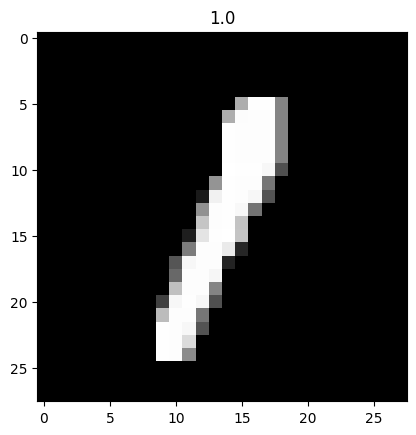

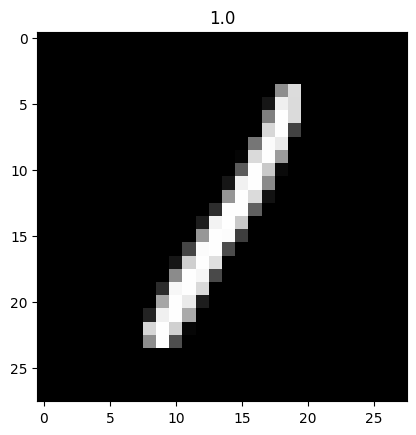

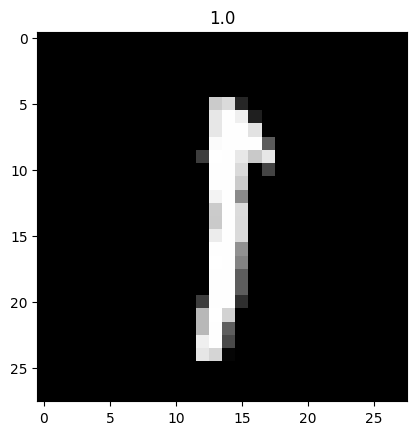

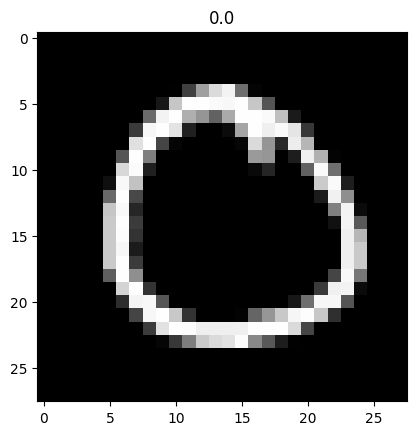

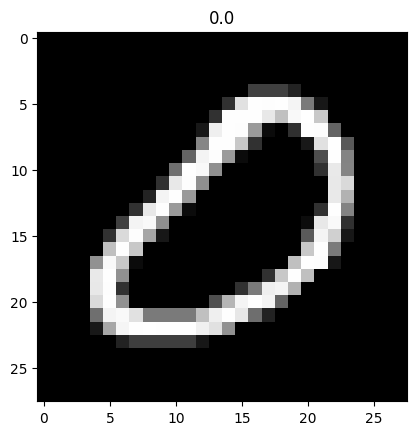

In [8]:
indices_img=[11450, 12585, 9520, 4587, 2351]

for ind_img in indices_img:
    im=X[ind_img]
    im = im.reshape((28,28))
    plt.figure()
    plt.imshow(im, cmap="Greys_r")
    plt.title(Y[ind_img])


## - Comparaison des performances de différents classifieurs

#### -  Entrainez et mesurez les performances des modèles suivants:
- SVM : linéaire et non -linéaire (RBF)
- Decision tree
- Random forest
- Régression logistique
.....

#### - Pour chaque modèle, lister et optimiser les hyperparamètres. Afficher les meilleures performances.

#### Astuce : utilisez la fonction GridSearchCV

--------------------
### SVM linéaire (https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html):
--------------------
#### Lister les hyperparamètres ici:
- XX



In [9]:
from sklearn import svm
parameters = {'C':[0.1, 1, 10, 100]}
svc = svm.SVC(kernel="linear")
svc.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'linear',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [10]:
clf_SVML = GridSearchCV(svc, parameters, cv=5)
clf_SVML.fit(Xtrain, Ytrain)

GridSearchCV(cv=5, estimator=SVC(kernel='linear'),
             param_grid={'C': [0.1, 1, 10, 100]})

In [11]:
print(clf_SVML.best_score_)
print(clf_SVML.best_estimator_.C)
clf_SVML.score(Xtest, Ytest)

0.8946
0.1


0.9082

In [12]:
Ytest_pred=clf_SVML.predict(Xtest)
print("Classification report for classifier %s:\n%s\n"
      % (clf_SVML, metrics.classification_report(Ytest, Ytest_pred)))

Classification report for classifier GridSearchCV(cv=5, estimator=SVC(kernel='linear'),
             param_grid={'C': [0.1, 1, 10, 100]}):
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.96       980
         1.0       0.94      0.98      0.96      1135
         2.0       0.90      0.89      0.90      1032
         3.0       0.87      0.89      0.88      1010
         4.0       0.88      0.93      0.91       982
         5.0       0.89      0.86      0.87       892
         6.0       0.95      0.96      0.95       958
         7.0       0.91      0.89      0.90      1028
         8.0       0.88      0.84      0.86       974
         9.0       0.91      0.85      0.88      1009

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000




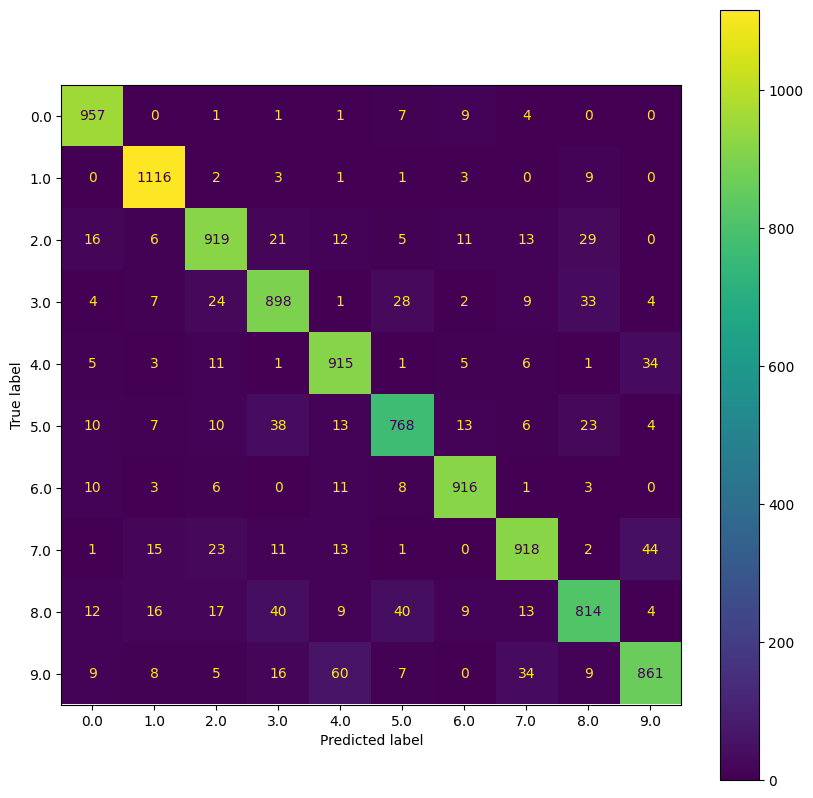

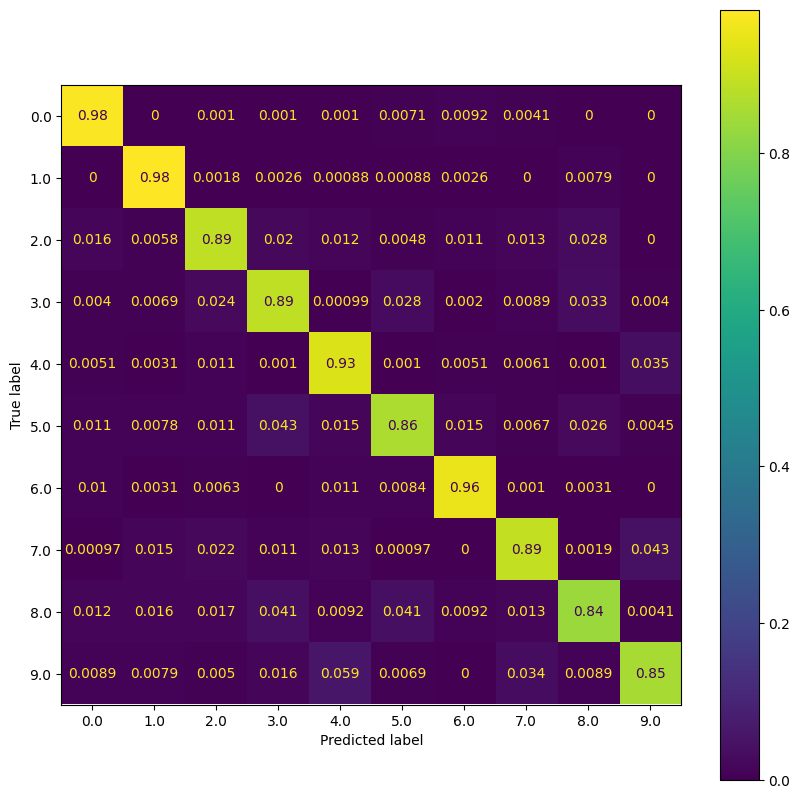

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_SVML, Xtest, Ytest)
plt.close()  # close the 1st small figure generated by ConfusionMatrixDisplay
display.plot(ax=ax)

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_SVML, Xtest, Ytest, normalize='true')
plt.close()
display.plot(ax=ax)

In [14]:
#For sklearn <0.22
digit_names=np.asarray(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])
np.set_printoptions(precision=1)
plot_confusion_matrix(Ytest, Ytest_pred, classes = digit_names,title='Confusion matrix, without normalization')
plot_confusion_matrix(Ytest, Ytest_pred, classes=digit_names, normalize=True, title='Normalized confusion matrix')
plt.show()

IndexError: arrays used as indices must be of integer (or boolean) type

*************************************
### Non linear SVM with rbf kernel
*************************************
#### List of hyperparameters:
- XX
- XX

In [15]:
parameters = {'gamma':[0.001, 0.01, 0.1], 'C':[1, 10]}
svc = svm.SVC(kernel="rbf")
svc.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

### A vous de jouer

0.925
10
Classification report for classifier GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 10], 'gamma': [0.001, 0.01, 0.1]}):
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97       980
         1.0       0.97      0.99      0.98      1135
         2.0       0.88      0.94      0.91      1032
         3.0       0.94      0.95      0.94      1010
         4.0       0.94      0.95      0.94       982
         5.0       0.95      0.92      0.93       892
         6.0       0.95      0.96      0.96       958
         7.0       0.94      0.92      0.93      1028
         8.0       0.93      0.91      0.92       974
         9.0       0.95      0.89      0.92      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000




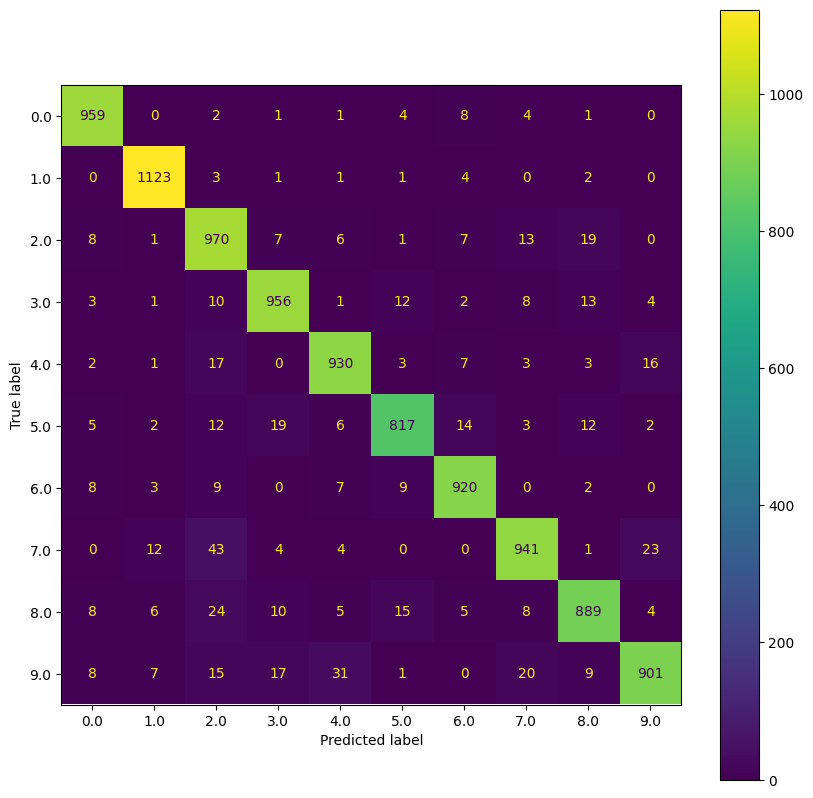

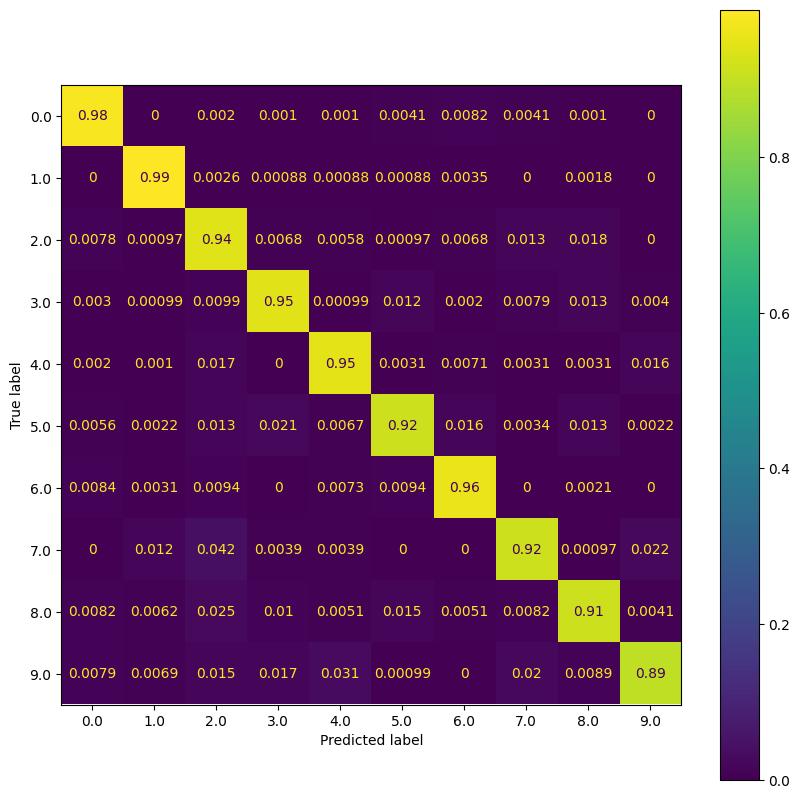

In [16]:

clf_SVML = GridSearchCV(svc, parameters, cv=5)
clf_SVML.fit(Xtrain, Ytrain)

print(clf_SVML.best_score_)
print(clf_SVML.best_estimator_.C)
clf_SVML.score(Xtest, Ytest)

Ytest_pred=clf_SVML.predict(Xtest)
print("Classification report for classifier %s:\n%s\n"
      % (clf_SVML, metrics.classification_report(Ytest, Ytest_pred)))

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_SVML, Xtest, Ytest)
plt.close()  # close the 1st small figure generated by ConfusionMatrixDisplay
display.plot(ax=ax)

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_SVML, Xtest, Ytest, normalize='true')
plt.close()
display.plot(ax=ax)

*************************************
### Logistic regression
*************************************
#### List of hyperparameters:
- XX
- XX


### A vous de jouer

/sync/IMI/env-imi/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/sync/IMI/env-imi/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
 

0.8732
1
Classification report for classifier GridSearchCV(cv=5, estimator=LogisticRegression(), param_grid={'C': [1, 10]}):
              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94       980
         1.0       0.95      0.97      0.96      1135
         2.0       0.89      0.82      0.85      1032
         3.0       0.87      0.86      0.86      1010
         4.0       0.87      0.89      0.88       982
         5.0       0.84      0.82      0.83       892
         6.0       0.92      0.93      0.92       958
         7.0       0.88      0.90      0.89      1028
         8.0       0.81      0.82      0.82       974
         9.0       0.87      0.86      0.86      1009

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000




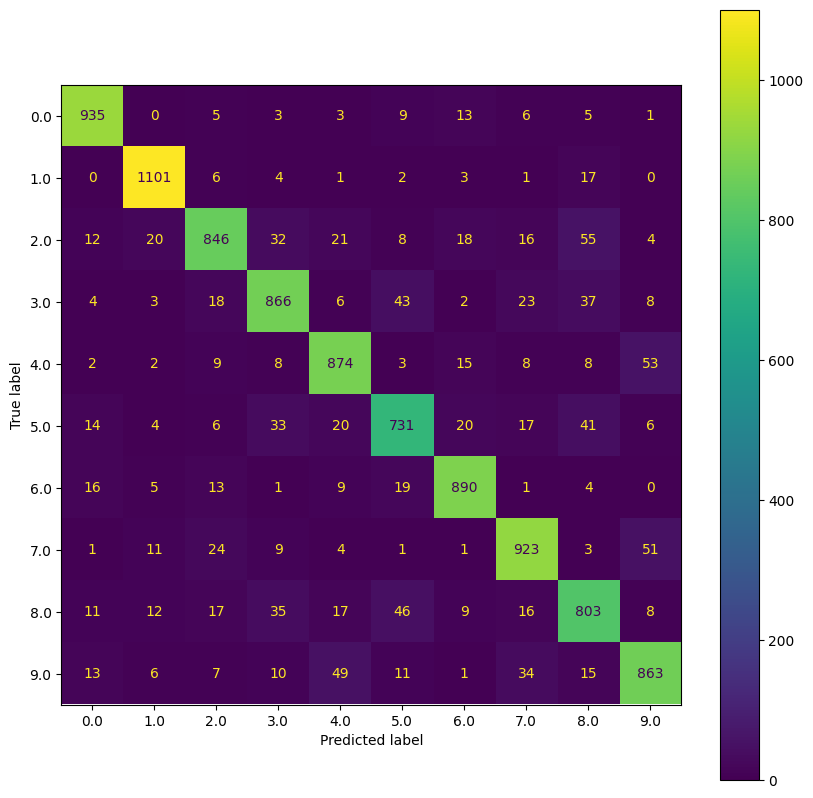

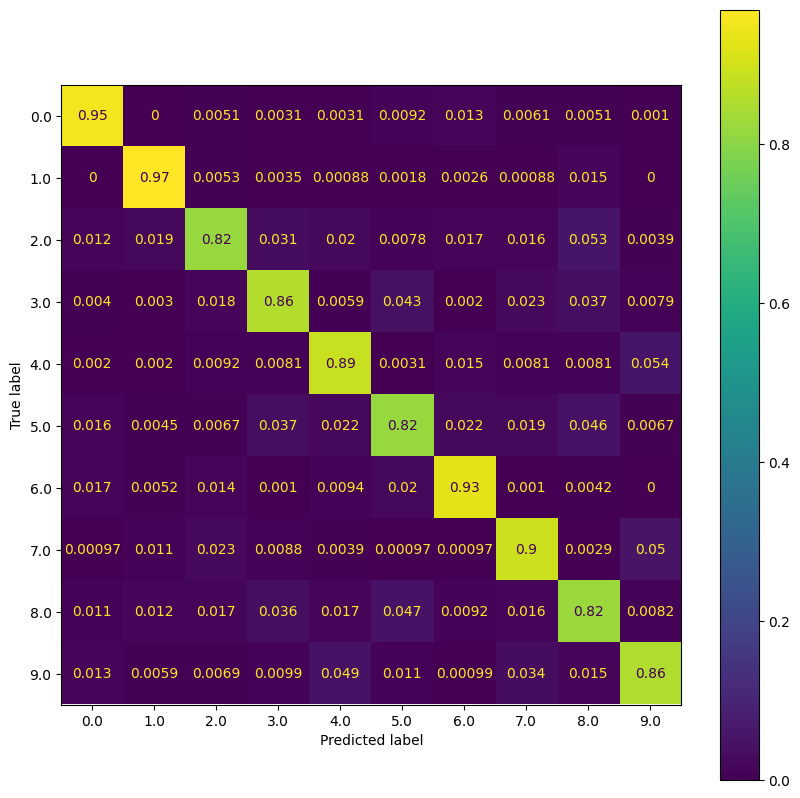

In [18]:
from sklearn.linear_model import LogisticRegression
parameters = {'C':[1, 10]}
svc = LogisticRegression()
svc.get_params()

clf_SVML = GridSearchCV(svc, parameters, cv=5)
clf_SVML.fit(Xtrain, Ytrain)

print(clf_SVML.best_score_)
print(clf_SVML.best_estimator_.C)
clf_SVML.score(Xtest, Ytest)

Ytest_pred=clf_SVML.predict(Xtest)
print("Classification report for classifier %s:\n%s\n"
      % (clf_SVML, metrics.classification_report(Ytest, Ytest_pred)))

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_SVML, Xtest, Ytest)
plt.close()  # close the 1st small figure generated by ConfusionMatrixDisplay
display.plot(ax=ax)

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_SVML, Xtest, Ytest, normalize='true')
plt.close()
display.plot(ax=ax)

*************************************
### Decision tree (https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier)
*************************************
#### List of hyperparameters:
- XX

In [37]:
# Decision Tree
from sklearn import tree
parameters = {'criterion':['gini','entropy'],'max_features':[0.25,0.5,0.75,0.99]}
svc=tree.DecisionTreeClassifier()
svc.get_params()


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': None,
 'splitter': 'best'}

0.7736
DecisionTreeClassifier(criterion='entropy', max_features=0.99)
Classification report for classifier GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_features': [0.25, 0.5, 0.75, 0.99]}):
              precision    recall  f1-score   support

         0.0       0.87      0.88      0.88       980
         1.0       0.92      0.92      0.92      1135
         2.0       0.74      0.75      0.74      1032
         3.0       0.71      0.72      0.71      1010
         4.0       0.79      0.74      0.77       982
         5.0       0.69      0.67      0.68       892
         6.0       0.79      0.82      0.81       958
         7.0       0.84      0.84      0.84      1028
         8.0       0.70      0.69      0.70       974
         9.0       0.72      0.74      0.73      1009

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighte

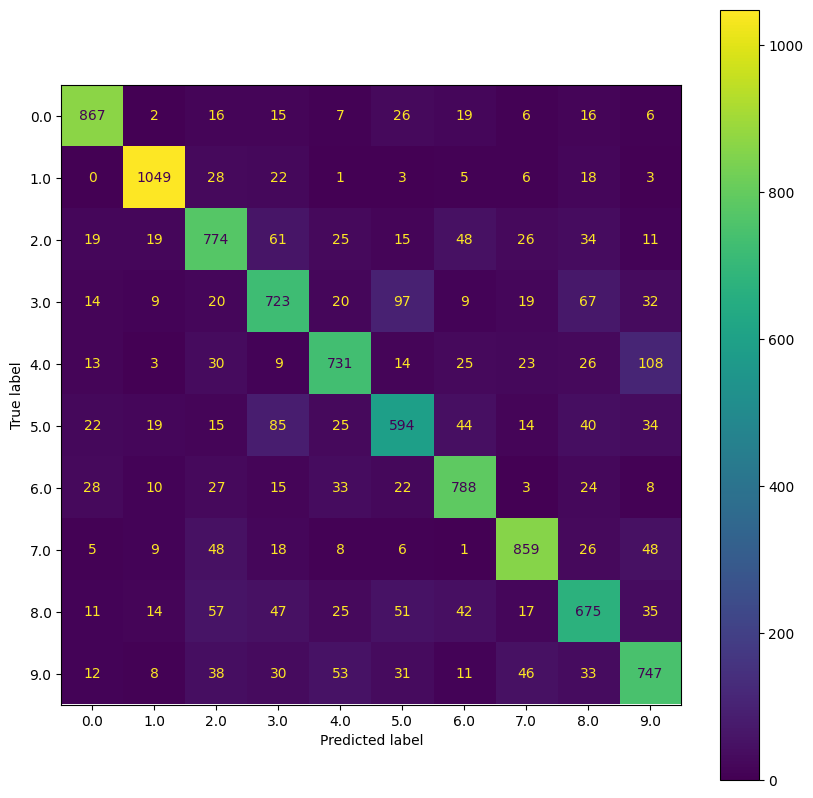

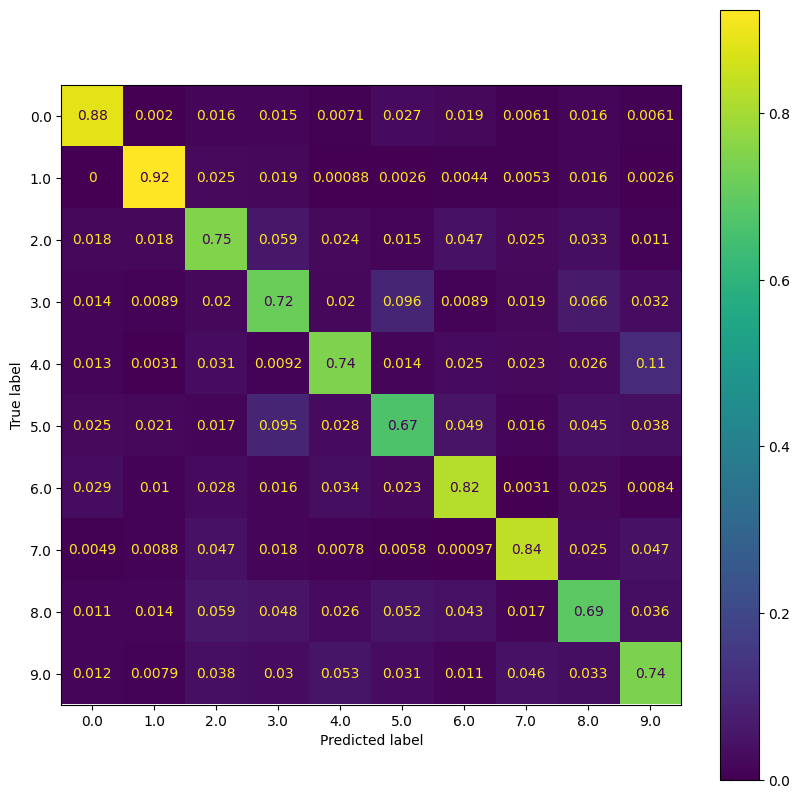

In [38]:
clf_DT = GridSearchCV(svc, parameters, cv=5)
clf_DT.fit(Xtrain, Ytrain)

print(clf_DT.best_score_)
print(clf_DT.best_estimator_)
clf_DT.score(Xtest, Ytest)

Ytest_pred=clf_DT.predict(Xtest)
print("Classification report for classifier %s:\n%s\n"
      % (clf_DT, metrics.classification_report(Ytest, Ytest_pred)))

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_DT, Xtest, Ytest)
plt.close()  # close the 1st small figure generated by ConfusionMatrixDisplay
display.plot(ax=ax)

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_DT, Xtest, Ytest, normalize='true')
plt.close()
display.plot(ax=ax)

[Text(0.5022169917402682, 0.96875, 'x[378] <= -0.202\nentropy = 3.318\nsamples = 5000\nvalue = [516, 545, 481, 557, 453, 442, 475, 500, 500, 531]'),
 Text(0.26346934290153745, 0.90625, 'x[568] <= -0.611\nentropy = 3.047\nsamples = 2620\nvalue = [503, 11, 310, 82, 330, 205, 305, 451, 143, 280]'),
 Text(0.14989419774288518, 0.84375, 'x[458] <= -0.704\nentropy = 2.785\nsamples = 1562\nvalue = [67, 6, 47, 46, 324, 106, 175, 439, 77, 275]'),
 Text(0.07578917239123324, 0.78125, 'x[404] <= -0.823\nentropy = 2.259\nsamples = 717\nvalue = [24, 6, 22, 38, 43, 54, 15, 409, 56, 50]'),
 Text(0.04579653254824992, 0.71875, 'x[154] <= -0.73\nentropy = 1.39\nsamples = 515\nvalue = [21, 5, 19, 19, 6, 13, 8, 403, 2, 19]'),
 Text(0.03140333660451423, 0.65625, 'x[513] <= -0.644\nentropy = 0.915\nsamples = 460\nvalue = [9, 4, 7, 3, 6, 5, 5, 401, 1, 19]'),
 Text(0.024206738632646385, 0.59375, 'x[622] <= 0.305\nentropy = 0.563\nsamples = 429\nvalue = [8, 4, 5, 3, 0, 3, 0, 398, 1, 7]'),
 Text(0.019627085377821

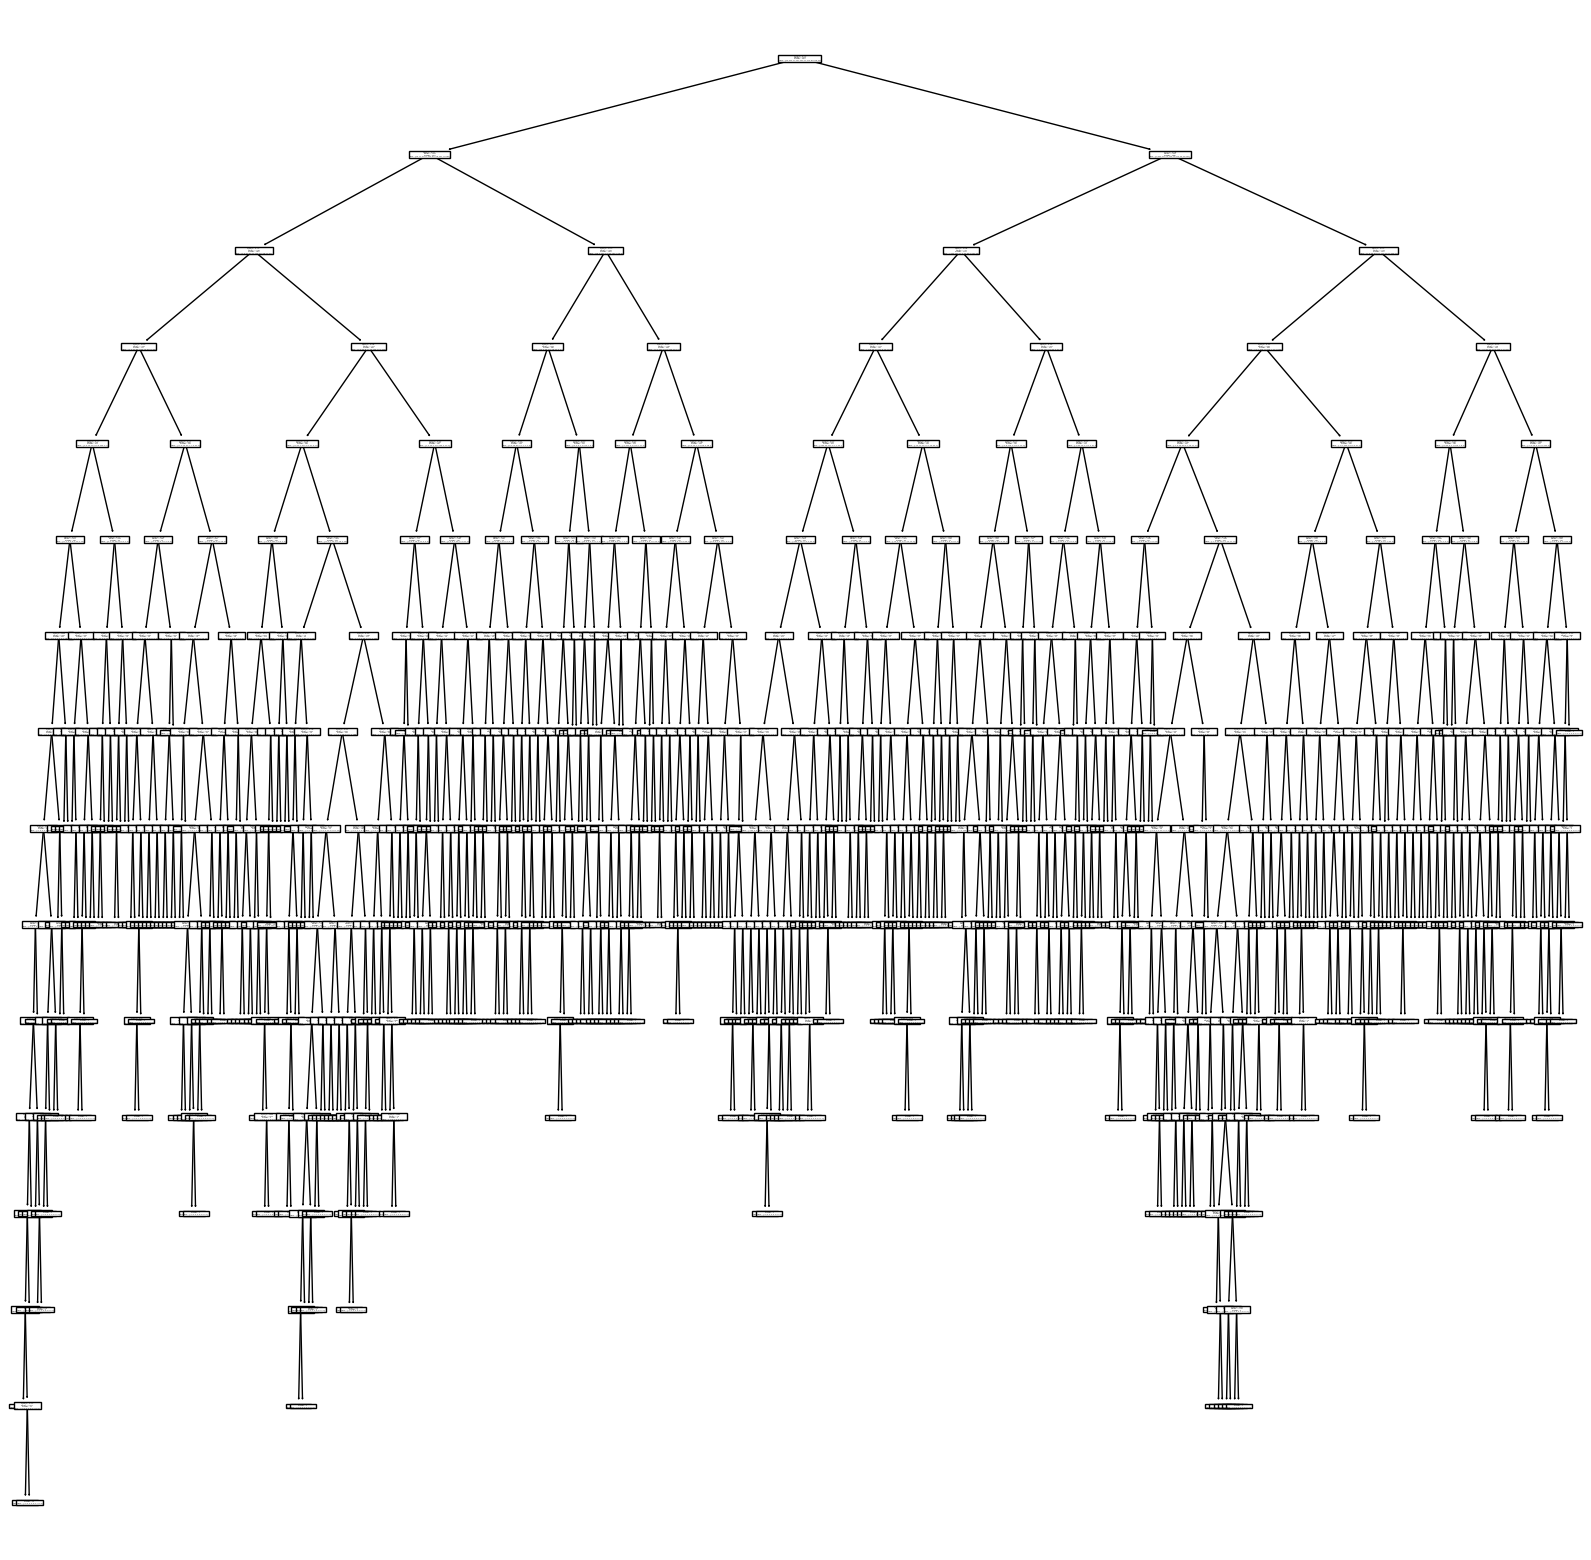

In [39]:
plt.figure(figsize=(20, 20))
tree.plot_tree(clf_DT.best_estimator_)

*************************************
### Random forest (https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
*************************************
#### List of hyperparameters:
- n_estimators= Number of trees
- criterion{“gini”, “entropy”}, default=”gini”
- splitter{“best”, “random”}, default=”best”
- max_depthint, default=None
- min_samples_splitint or float, default=2
- max_features

In [44]:
from sklearn.ensemble import RandomForestClassifier

0.9236000000000001
RandomForestClassifier(criterion='entropy', max_features=0.25)
Classification report for classifier GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_features': [0.25, 0.5, 0.75, 0.99]}):
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95       980
         1.0       0.97      0.98      0.98      1135
         2.0       0.94      0.91      0.92      1032
         3.0       0.93      0.92      0.92      1010
         4.0       0.93      0.92      0.92       982
         5.0       0.92      0.90      0.91       892
         6.0       0.94      0.94      0.94       958
         7.0       0.94      0.93      0.94      1028
         8.0       0.90      0.92      0.91       974
         9.0       0.89      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     1

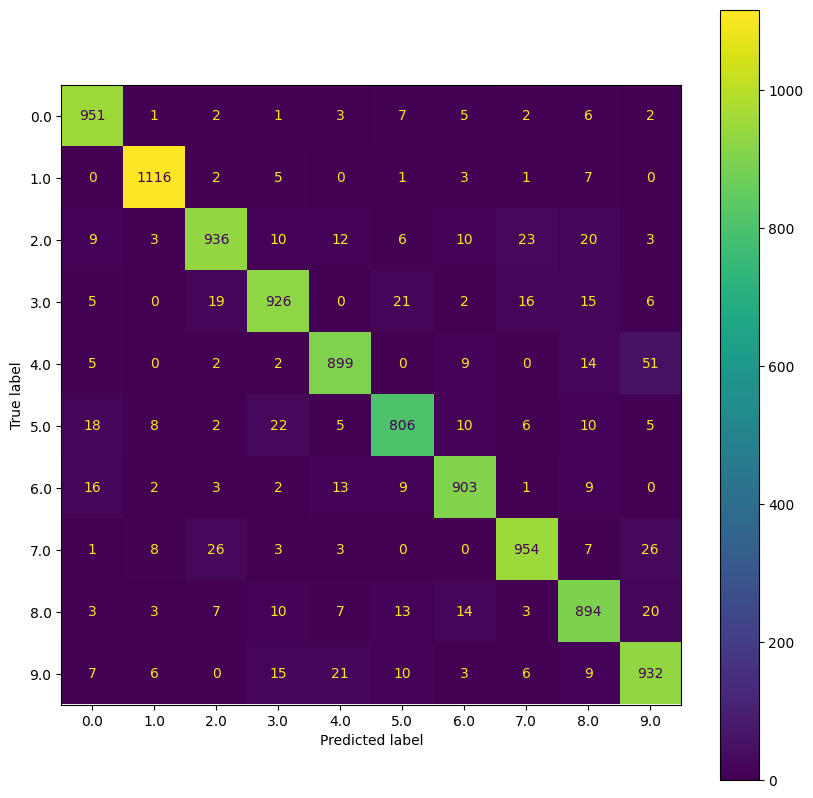

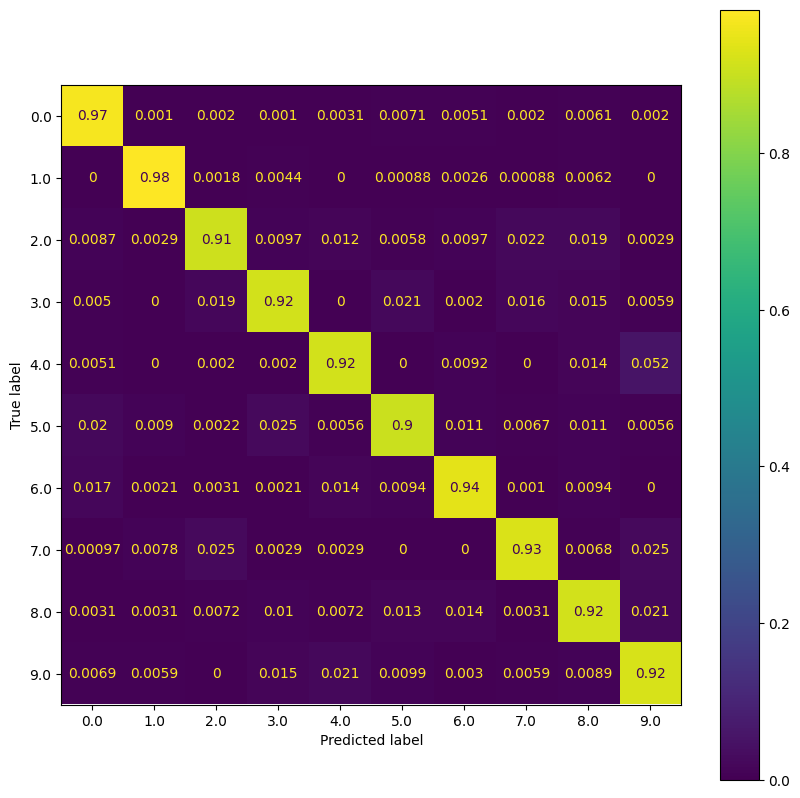

In [45]:
parameters = {'criterion':['gini','entropy'],'max_features':[0.25,0.5,0.75,0.99]}
svc=RandomForestClassifier()
svc.get_params()
clf_DT = GridSearchCV(svc, parameters, cv=5)
clf_DT.fit(Xtrain, Ytrain)

print(clf_DT.best_score_)
print(clf_DT.best_estimator_)
clf_DT.score(Xtest, Ytest)

Ytest_pred=clf_DT.predict(Xtest)
print("Classification report for classifier %s:\n%s\n"
      % (clf_DT, metrics.classification_report(Ytest, Ytest_pred)))

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_DT, Xtest, Ytest)
plt.close()  # close the 1st small figure generated by ConfusionMatrixDisplay
display.plot(ax=ax)

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_DT, Xtest, Ytest, normalize='true')
plt.close()
display.plot(ax=ax)


*************************************
### Neural network - perceptron
*************************************
#### List of hyperparameters:
-   mlp = MLPClassifier(
    hidden_layer_sizes=(40,),
    max_iter=8,
    alpha=1e-4,
    solver="sgd",
    verbose=10,
    random_state=1,
    learning_rate_init=0.2,
- XX


In [46]:
from sklearn.neural_network import MLPClassifier

In [49]:
parameters = {'criterion':['gini','entropy'],'max_features':[0.25,0.5,0.75,0.99]}
MLP=MLPClassifier(random_state=1, hidden_layer_sizes=(40,30))
MLP.get_params()
clf_MLP = GridSearchCV(svc, parameters, cv=5)
clf_MLP.fit(Xtrain, Ytrain)

print(clf_DT.best_score_)
print(clf_DT.best_estimator_)
clf_MLP.score(Xtest, Ytest)

Ytest_pred=clf_MLP.predict(Xtest)
print("Classification report for classifier %s:\n%s\n"
      % (clf_MLP, metrics.classification_report(Ytest, Ytest_pred)))

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_MLP, Xtest, Ytest)
plt.close()  # close the 1st small figure generated by ConfusionMatrixDisplay
display.plot(ax=ax)

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay.from_estimator(clf_MLP, Xtest, Ytest, normalize='true')
plt.close()
display.plot(ax=ax)

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(20, 20))
tree.plot_tree(clf_MLP.best_estimator_)

## Feature extraction (optional)

Extract other feature types from the original MNIST data, eg
HOG features (see https://scikit-image.org/docs/dev/auto_examples/features_detection/plot_hog.html)

Estimate the best performance achieved with this new feature set. How does it compare to the performance achieved with the original grey level features?

https://github.com/OSSpk/Handwritten-Digits-Classification-Using-KNN-Multiclass_Perceptron-SVM/blob/master/Code/multiclass_classification.py

1.0
(28, 28)
(112, 112)


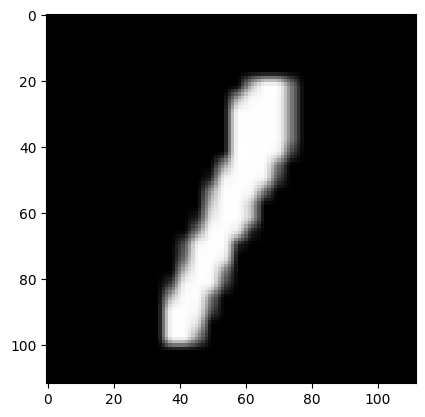

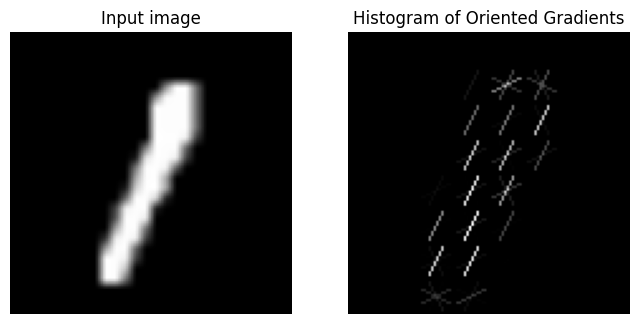

In [60]:
from skimage.feature import hog
from skimage import data, exposure
from skimage.transform import rescale, resize, downscale_local_mean

ind_img=11450
im=X[ind_img]
print(Y[ind_img])
im = im.reshape((28,28))
print(im.shape)

im_res=resize(im,(112,112), anti_aliasing=True)
image = im_res

print(image.shape)
plt.imshow(image, cmap="Greys_r")

fd, hog_image = hog(image, orientations=4, pixels_per_cell=(14, 14), cells_per_block=(1, 1), visualize=True)
fd.shape

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

In [61]:
X_hog=np.zeros((X.shape[0],256))
toto=np.zeros(256)
for k in range (0, 100):
#for k in range (0, X.shape[0]):
    im=X[k]
    im = im.reshape((28,28))
    im_res=resize(im,(112,112), anti_aliasing=True)
    fd, hog_image = hog(im_res, orientations=4, pixels_per_cell=(14, 14), cells_per_block=(1, 1), visualize=True)
    X_hog[k,:]=fd[:]